# Flight Price Prediction - Machine Learning Project

## Objective
Build a **Linear Regression model** to predict flight prices based on multiple features such as:
- Airline
- Flight duration
- Days left until departure
- Number of stops
- Departure/arrival times
- Source/destination cities
- Class (economy, business, etc.)

## Dataset
**Source:** Kaggle - Airlines Flights Data  
**Target Variable:** `price` (continuous, regression task)

## Pipeline Overview
1. ✓ Load and inspect dataset
2. Exploratory Data Analysis (EDA)
3. Create visualizations
4. Data cleaning
5. Data preprocessing & encoding
6. Feature scaling
7. Train-test split
8. Model training (Linear Regression)
9. Model evaluation
10. Save model

## Step 1: Load Dataset from Kaggle

In [64]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully\n")

# Download latest version of airlines dataset
path = kagglehub.dataset_download("rohitgrewal/airlines-flights-data")
print(f" Dataset downloaded to: {path}\n")

# List available files
files = os.listdir(path)
print(f"Available files: {files}\n")

# Load the CSV file
full_path = os.path.join(path, files[0])
df = pd.read_csv(full_path)
print(f"Dataset loaded successfully!\n")

All libraries imported successfully

 Dataset downloaded to: C:\Users\Doha\.cache\kagglehub\datasets\rohitgrewal\airlines-flights-data\versions\1

Available files: ['airlines_flights_data.csv']

Dataset loaded successfully!



## Step 2: Exploratory Data Analysis (EDA)

In [65]:
print("DATASET OVERVIEW")
print(f"\nShape: {df.shape} (rows, columns)")
print(f"\nFirst 5 rows:")
print(df.head())

DATASET OVERVIEW

Shape: (300153, 12) (rows, columns)

First 5 rows:
   index   airline   flight source_city departure_time stops   arrival_time  \
0      0  SpiceJet  SG-8709       Delhi        Evening  zero          Night   
1      1  SpiceJet  SG-8157       Delhi  Early_Morning  zero        Morning   
2      2   AirAsia   I5-764       Delhi  Early_Morning  zero  Early_Morning   
3      3   Vistara   UK-995       Delhi        Morning  zero      Afternoon   
4      4   Vistara   UK-963       Delhi        Morning  zero        Morning   

  destination_city    class  duration  days_left  price  
0           Mumbai  Economy      2.17          1   5953  
1           Mumbai  Economy      2.33          1   5953  
2           Mumbai  Economy      2.17          1   5956  
3           Mumbai  Economy      2.25          1   5955  
4           Mumbai  Economy      2.33          1   5955  


In [66]:
print("DATA TYPES AND INFO")
print(df.info())

DATA TYPES AND INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   index             300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB
None


In [67]:
print("DESCRIPTIVE STATISTICS")   
print(df.describe())

DESCRIPTIVE STATISTICS
               index       duration      days_left          price
count  300153.000000  300153.000000  300153.000000  300153.000000
mean   150076.000000      12.221021      26.004751   20889.660523
std     86646.852011       7.191997      13.561004   22697.767366
min         0.000000       0.830000       1.000000    1105.000000
25%     75038.000000       6.830000      15.000000    4783.000000
50%    150076.000000      11.250000      26.000000    7425.000000
75%    225114.000000      16.170000      38.000000   42521.000000
max    300152.000000      49.830000      49.000000  123071.000000


In [68]:
print("MISSING VALUES")    
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else " No missing values")

    
print("DUPLICATE ROWS")
print(f"Total duplicates: {df.duplicated().sum()}")
if df.duplicated().sum() > 0:
     print("Duplicate rows:")
     print(df[df.duplicated(keep=False)].sort_values(by=list(df.columns)))

MISSING VALUES
 No missing values
DUPLICATE ROWS
Total duplicates: 0


In [69]:
print("FEATURE ANALYSIS")
# Numerical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nNumeric columns: {numeric_cols}")

# Categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns: {categorical_cols}")

# Unique values per categorical column
print("\nUnique values per categorical column:")
for col in categorical_cols:
     print(f"    {col}: {df[col].nunique()} unique values")

FEATURE ANALYSIS

Numeric columns: ['index', 'duration', 'days_left', 'price']
Categorical columns: ['airline', 'flight', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class']

Unique values per categorical column:
    airline: 6 unique values
    flight: 1561 unique values
    source_city: 6 unique values
    departure_time: 6 unique values
    stops: 3 unique values
    arrival_time: 6 unique values
    destination_city: 6 unique values
    class: 2 unique values


## Step 3: Numeric Data Visualizations

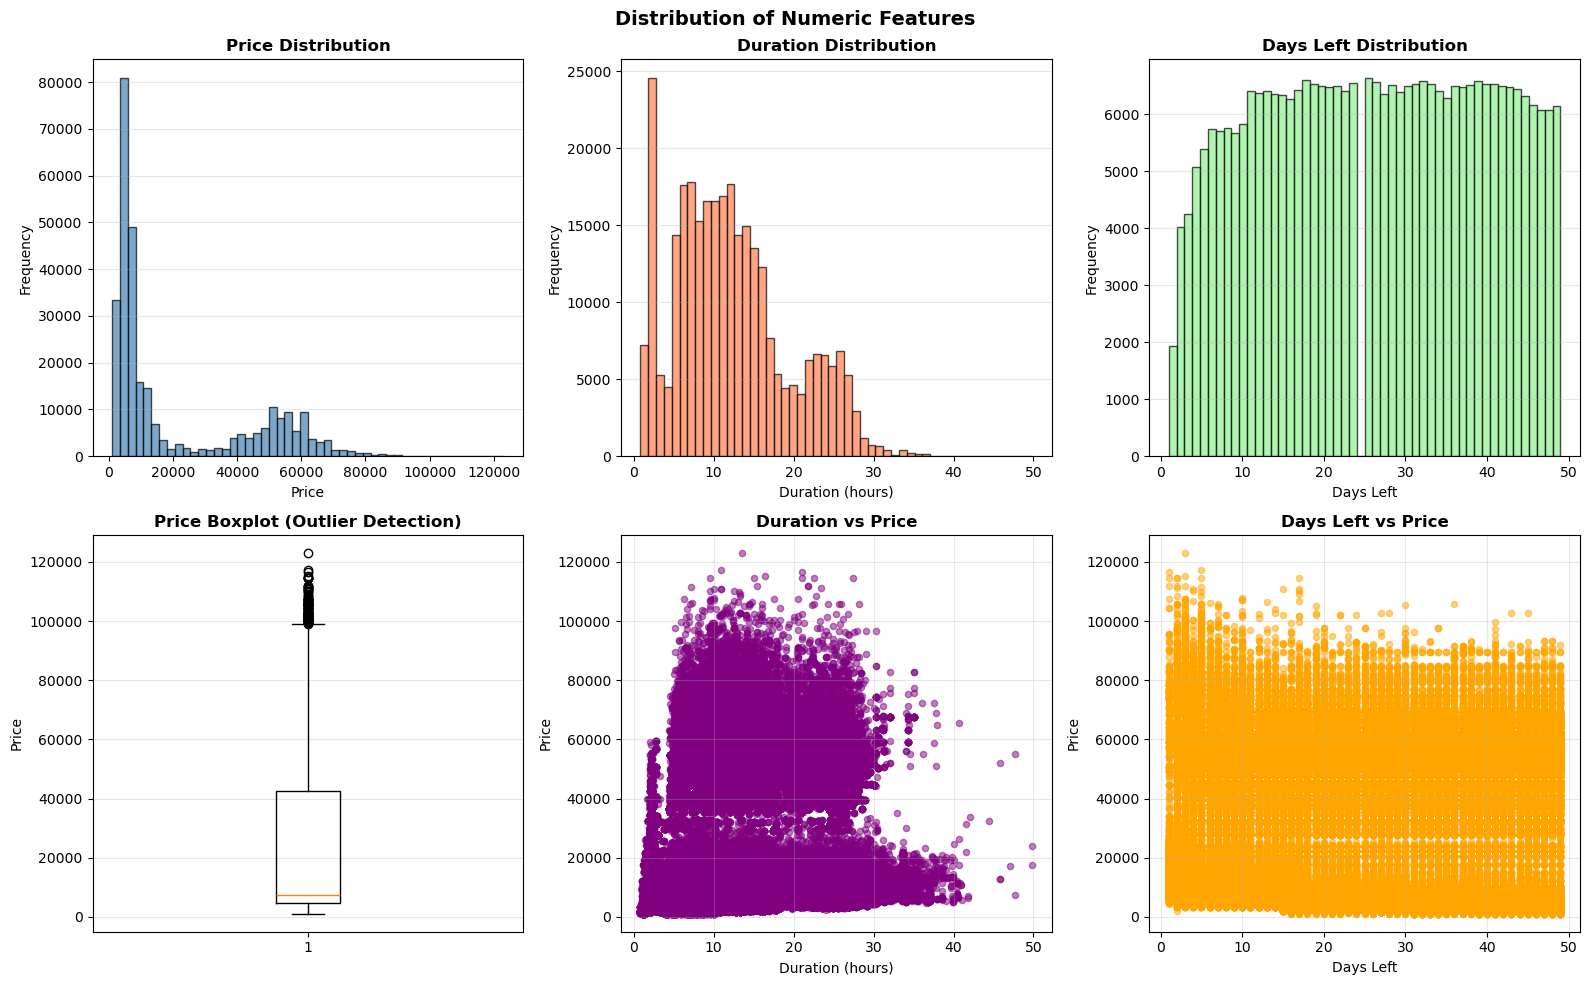

In [70]:
# Create figure for numeric distributions
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribution of Numeric Features', fontsize=14, fontweight='bold')

# Price distribution
ax = axes[0, 0]
ax.hist(df['price'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax.set_title('Price Distribution', fontweight='bold')
ax.set_xlabel('Price')
ax.set_ylabel('Frequency')
ax.grid(axis='y', alpha=0.3)

# Duration distribution
ax = axes[0, 1]
ax.hist(df['duration'], bins=50, color='coral', edgecolor='black', alpha=0.7)
ax.set_title('Duration Distribution', fontweight='bold')
ax.set_xlabel('Duration (hours)')
ax.set_ylabel('Frequency')
ax.grid(axis='y', alpha=0.3)

# Days left distribution
ax = axes[0, 2]
ax.hist(df['days_left'], bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
ax.set_title('Days Left Distribution', fontweight='bold')
ax.set_xlabel('Days Left')
ax.set_ylabel('Frequency')
ax.grid(axis='y', alpha=0.3)

# Price boxplot
ax = axes[1, 0]
ax.boxplot(df['price'], vert=True)
ax.set_title('Price Boxplot (Outlier Detection)', fontweight='bold')
ax.set_ylabel('Price')
ax.grid(axis='y', alpha=0.3)

# Duration vs Price scatter
ax = axes[1, 1]
ax.scatter(df['duration'], df['price'], alpha=0.5, s=20, color='purple')
ax.set_title('Duration vs Price', fontweight='bold')
ax.set_xlabel('Duration (hours)')
ax.set_ylabel('Price')
ax.grid(True, alpha=0.3)

# Days left vs Price scatter
ax = axes[1, 2]
ax.scatter(df['days_left'], df['price'], alpha=0.5, s=20, color='orange')
ax.set_title('Days Left vs Price', fontweight='bold')
ax.set_xlabel('Days Left')
ax.set_ylabel('Price')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 4: Categorical Data Visualizations

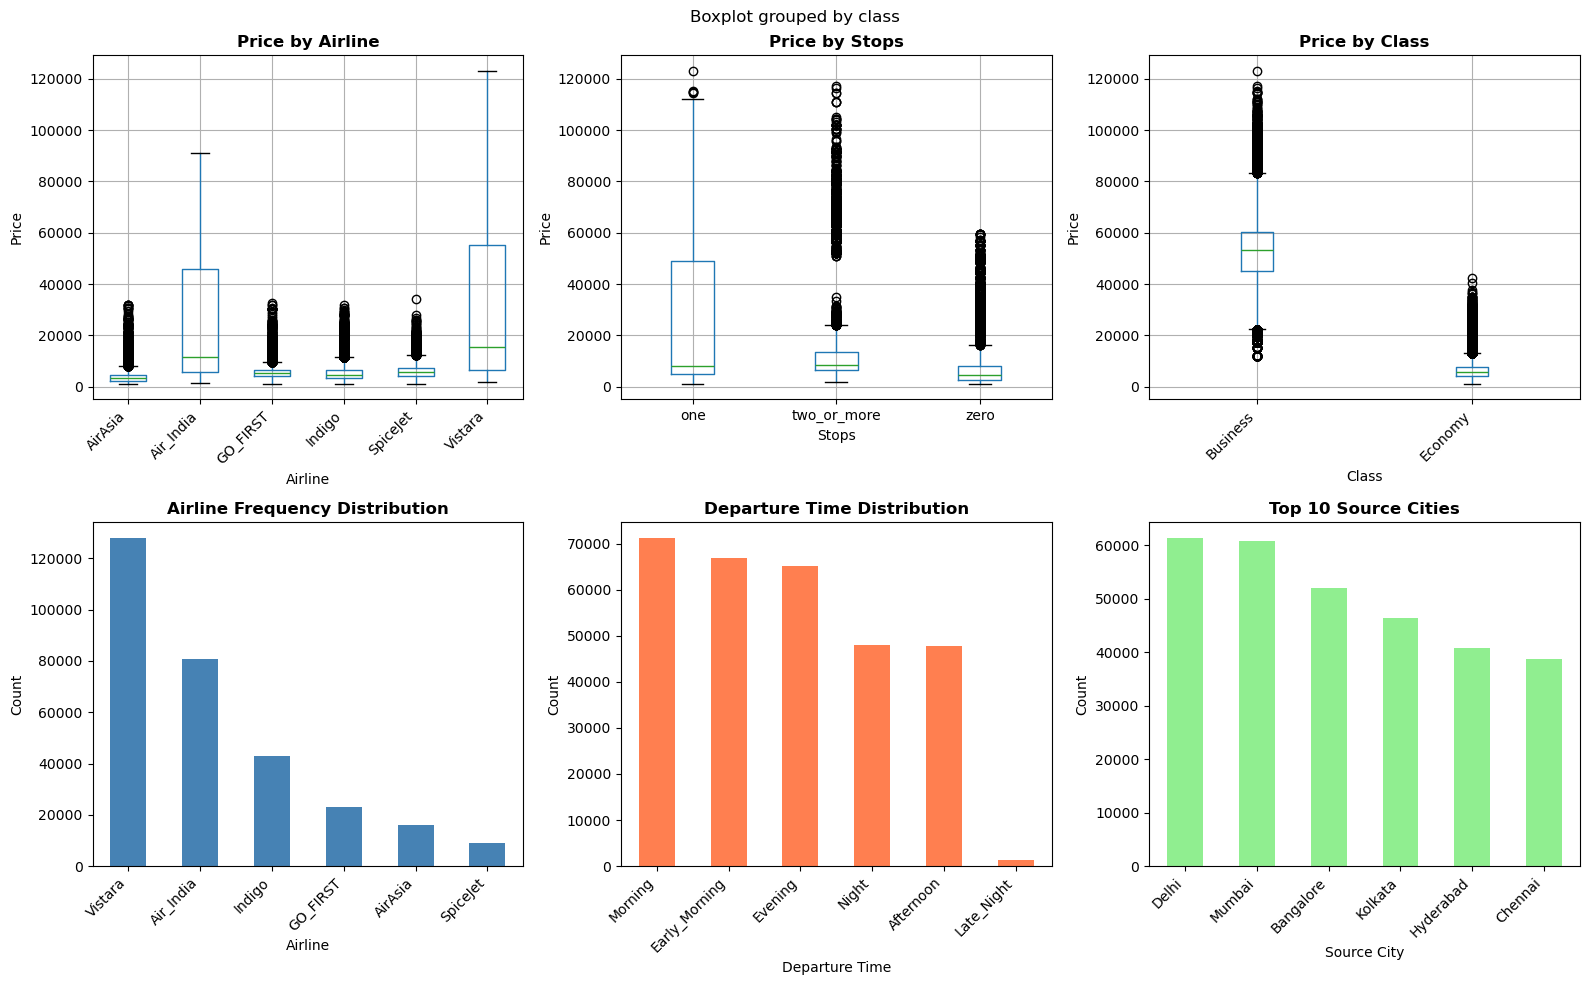

In [71]:
# Create figure for categorical analysis
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Categorical Feature Analysis', fontsize=14, fontweight='bold')

# Price by airline
ax = axes[0, 0]
df.boxplot(column='price', by='airline', ax=ax)
ax.set_title('Price by Airline', fontweight='bold')
ax.set_xlabel('Airline')
ax.set_ylabel('Price')
plt.sca(ax)
plt.xticks(rotation=45, ha='right')

# Price by number of stops
ax = axes[0, 1]
if 'stops' in df.columns:
     df.boxplot(column='price', by='stops', ax=ax)
     ax.set_title('Price by Stops', fontweight='bold')
     ax.set_xlabel('Stops')
     ax.set_ylabel('Price')
else:
     ax.text(0.5, 0.5, 'Stops column not found', ha='center', va='center')

# Price by class
ax = axes[0, 2]
if 'class' in df.columns:
     df.boxplot(column='price', by='class', ax=ax)
     ax.set_title('Price by Class', fontweight='bold')
     ax.set_xlabel('Class')
     ax.set_ylabel('Price')
     plt.sca(ax)
     plt.xticks(rotation=45, ha='right')
else:
     ax.text(0.5, 0.5, 'Class column not found', ha='center', va='center')

# Airline frequency
ax = axes[1, 0]
df['airline'].value_counts().plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Airline Frequency Distribution', fontweight='bold')
ax.set_xlabel('Airline')
ax.set_ylabel('Count')
plt.sca(ax)
plt.xticks(rotation=45, ha='right')

# Departure time frequency
ax = axes[1, 1]
if 'departure_time' in df.columns:
     df['departure_time'].value_counts().plot(kind='bar', ax=ax, color='coral')
     ax.set_title('Departure Time Distribution', fontweight='bold')
     ax.set_xlabel('Departure Time')
     ax.set_ylabel('Count')
     plt.sca(ax)
     plt.xticks(rotation=45, ha='right')

# Source city frequency
ax = axes[1, 2]
if 'source_city' in df.columns:
     df['source_city'].value_counts().head(10).plot(kind='bar', ax=ax, color='lightgreen')
     ax.set_title('Top 10 Source Cities', fontweight='bold')
     ax.set_xlabel('Source City')
     ax.set_ylabel('Count')
     plt.sca(ax)
     plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


## Step 5: Advanced Visualizations (Heatmaps & Correlations)

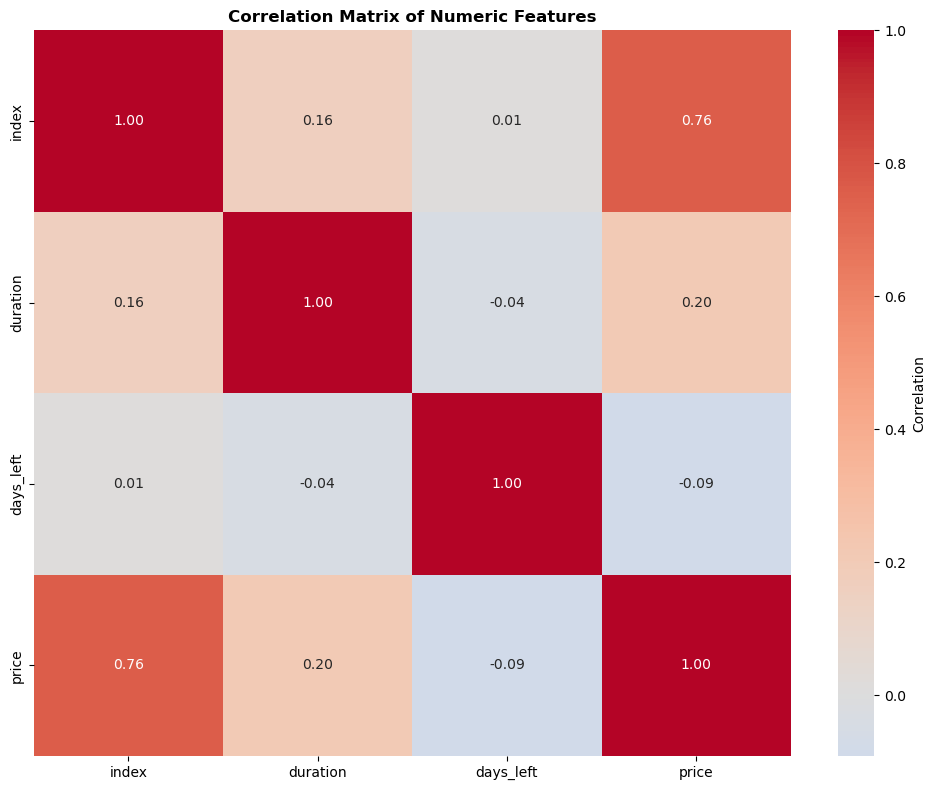

In [72]:
# Correlation heatmap for numeric features
fig, ax = plt.subplots(figsize=(10, 8))
numeric_data = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_data.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
               cbar_kws={'label': 'Correlation'}, ax=ax, fmt='.2f')
ax.set_title('Correlation Matrix of Numeric Features', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

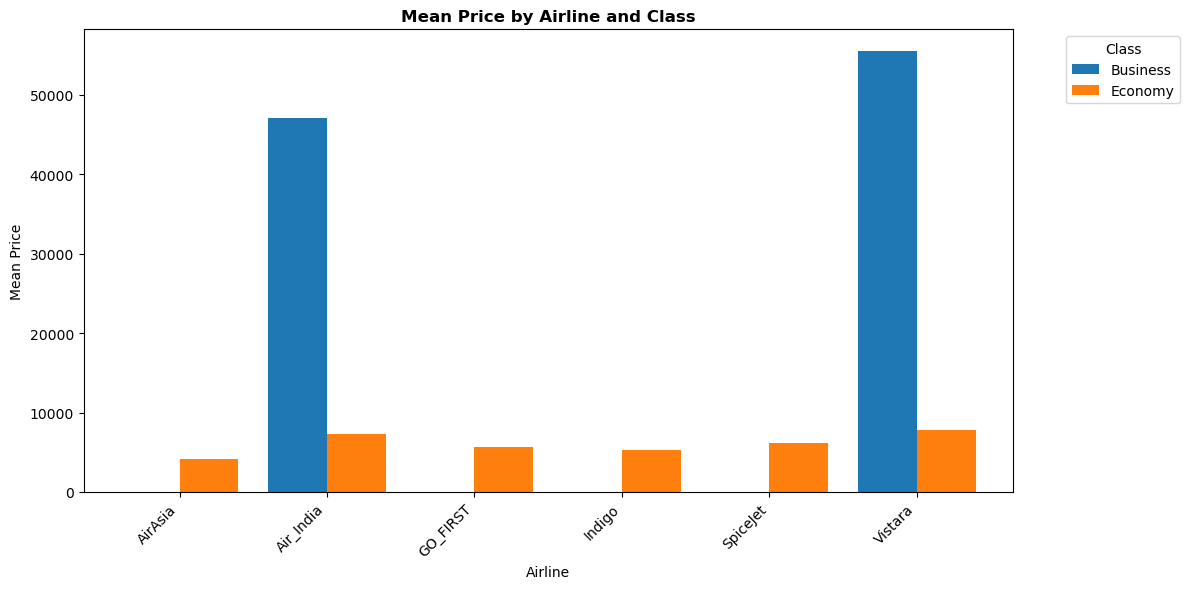

In [73]:
# Mean price by airline and class
if 'class' in df.columns:
     fig, ax = plt.subplots(figsize=(12, 6))
     pivot_table = df.groupby(['airline', 'class'])['price'].mean().unstack(fill_value=0)
     pivot_table.plot(kind='bar', ax=ax, width=0.8)
     ax.set_title('Mean Price by Airline and Class', fontweight='bold', fontsize=12)
     ax.set_xlabel('Airline')
     ax.set_ylabel('Mean Price')
     ax.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
     plt.xticks(rotation=45, ha='right')
     plt.tight_layout()
     plt.show()

## Step 6: Data Cleaning

In [74]:
print("BEFORE CLEANING:")
print(f"Shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")

# Remove duplicates
df = df.drop_duplicates()

# Check for missing values and handle them
if df.isnull().sum().sum() > 0:
     print("\nMissing values by column:")
     print(df.isnull().sum())
     # Fill missing values with appropriate methods
     for col in df.columns:
          if df[col].isnull().sum() > 0:
               if df[col].dtype == 'object':
                    df[col].fillna(df[col].mode()[0], inplace=True)    # Mode for categorical
               else:
                    df[col].fillna(df[col].median(), inplace=True)    # Median for numeric

print("\nAFTER CLEANING:")
print(f"Shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")

BEFORE CLEANING:
Shape: (300153, 12)
Missing values: 0
Duplicates: 0

AFTER CLEANING:
Shape: (300153, 12)
Missing values: 0
Duplicates: 0


## Step 7: Data Preprocessing & Encoding

In [75]:
# Create a copy for preprocessing
df_processed = df.copy()

# Separate target variable
X = df_processed.drop('price', axis=1)
y = df_processed['price']

print(f"Target variable (price) shape: {y.shape}")
print(f"Feature matrix shape before encoding: {X.shape}")
print(f"\nFeature columns: {X.columns.tolist()}")

# Identify categorical and numeric columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print(f"\nCategorical columns to encode: {categorical_cols}")
print(f"Numeric columns: {numeric_cols}")

# One-Hot Encoding for categorical variables
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(f"\nFeature matrix shape after encoding: {X_encoded.shape}")
print(f"\nEncoded feature columns: {X_encoded.columns.tolist()[:10]}... (showing first 10)")

Target variable (price) shape: (300153,)
Feature matrix shape before encoding: (300153, 11)

Feature columns: ['index', 'airline', 'flight', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class', 'duration', 'days_left']

Categorical columns to encode: ['airline', 'flight', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class']
Numeric columns: ['index', 'duration', 'days_left']

Feature matrix shape after encoding: (300153, 1591)

Encoded feature columns: ['index', 'duration', 'days_left', 'airline_Air_India', 'airline_GO_FIRST', 'airline_Indigo', 'airline_SpiceJet', 'airline_Vistara', 'flight_6.00E-102', 'flight_6.00E-105']... (showing first 10)


## Step 8: Feature Scaling

In [76]:
# Initialize scaler for numeric features (exclude encoded categorical features which are binary)
scaler = StandardScaler()

# Scale only the numeric columns
X_scaled = X_encoded.copy()
X_scaled[numeric_cols] = scaler.fit_transform(X_encoded[numeric_cols])

print("SCALED DATA STATISTICS (Numeric Features):")
print("\nBefore Scaling:")
print(X_encoded[numeric_cols].describe())

print("\nAfter Scaling:")
print(X_scaled[numeric_cols].describe())

print("\nFeature scaling completed")
print(f"Scaled feature matrix shape: {X_scaled.shape}")

SCALED DATA STATISTICS (Numeric Features):

Before Scaling:
               index       duration      days_left
count  300153.000000  300153.000000  300153.000000
mean   150076.000000      12.221021      26.004751
std     86646.852011       7.191997      13.561004
min         0.000000       0.830000       1.000000
25%     75038.000000       6.830000      15.000000
50%    150076.000000      11.250000      26.000000
75%    225114.000000      16.170000      38.000000
max    300152.000000      49.830000      49.000000

After Scaling:
              index      duration     days_left
count  3.001530e+05  3.001530e+05  3.001530e+05
mean  -4.848166e-17  7.272249e-17  1.219617e-16
std    1.000002e+00  1.000002e+00  1.000002e+00
min   -1.732045e+00 -1.583849e+00 -1.843875e+00
25%   -8.660225e-01 -7.495873e-01 -8.115011e-01
50%    0.000000e+00 -1.350143e-01 -3.503368e-04
75%    8.660225e-01  5.490805e-01  8.845414e-01
max    1.732045e+00  5.229290e+00  1.695692e+00

Feature scaling completed
Scaled

## Step 9: Train-Test Split

In [77]:
# Split data into train (80%) and test (20%)
X_train, X_test, y_train, y_test = train_test_split(
     X_scaled, y, test_size=0.20, random_state=42
)

print("TRAIN-TEST SPLIT (80/20)")
print(f"\nTotal samples          : {len(X_scaled)}")
print(f"Training samples      : {len(X_train)} ({100*len(X_train)/len(X_scaled):.1f}%)")
print(f"Test samples           : {len(X_test)} ({100*len(X_test)/len(X_scaled):.1f}%)")
print(f"\nNumber of features     : {X_train.shape[1]}")
print(f"\nTarget variable (Price) statistics:")
print(f"    Train set - Mean: {y_train.mean():.2f}, Std: {y_train.std():.2f}")
print(f"    Test set    - Mean: {y_test.mean():.2f}, Std: {y_test.std():.2f}")

TRAIN-TEST SPLIT (80/20)

Total samples          : 300153
Training samples      : 240122 (80.0%)
Test samples           : 60031 (20.0%)

Number of features     : 1591

Target variable (Price) statistics:
    Train set - Mean: 20888.57, Std: 22696.15
    Test set    - Mean: 20894.01, Std: 22704.42


## Step 10: Model Training

In [ ]:
# Create and train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

print("LINEAR REGRESSION MODEL TRAINING")
print(f"\nModel Parameters:")
print(f"    Number of features     : {len(model.coef_)}")
print(f"    Intercept                : {model.intercept_:.4f}")
print(f"\nTop 10 Most Important Features (by coefficient magnitude):")
feature_importance = pd.DataFrame({
     'Feature': X_scaled.columns,
     'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=False).head(10)

print(feature_importance.to_string(index=False))

## Step 11: Model Evaluation

In [ ]:
# Make predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Calculate metrics
def calculate_metrics(y_true, y_pred, set_name):
     mae = mean_absolute_error(y_true, y_pred)
     mse = mean_squared_error(y_true, y_pred)
     rmse = np.sqrt(mse)
     r2 = r2_score(y_true, y_pred)
     
     print(f"\n{'─'*50}")
     print(f"{set_name}")
     print(f"{'─'*50}")
     print(f"    MAE    (Mean Absolute Error)     : {mae:>10.2f}")
     print(f"    MSE    (Mean Squared Error)      : {mse:>10.2f}")
     print(f"    RMSE (Root Mean Squared Err.) : {rmse:>10.2f}")
     print(f"    R²     (Coefficient of Determ.) : {r2:>10.4f}")
     
     return mae, mse, rmse, r2

print("MODEL PERFORMANCE EVALUATION")

train_mae, train_mse, train_rmse, train_r2 = calculate_metrics(y_train, y_train_pred, "TRAINING SET")
test_mae, test_mse, test_rmse, test_r2 = calculate_metrics(y_test, y_test_pred, "TEST SET")


MODEL PERFORMANCE EVALUATION

──────────────────────────────────────────────────
TRAINING SET
──────────────────────────────────────────────────
    MAE    (Mean Absolute Error)     :    4231.54
    MSE    (Mean Squared Error)      : 37713450.51
    RMSE (Root Mean Squared Err.) :    6141.13
    R²     (Coefficient of Determ.) :     0.9268

──────────────────────────────────────────────────
TEST SET
──────────────────────────────────────────────────
    MAE    (Mean Absolute Error)     :    4230.62
    MSE    (Mean Squared Error)      : 38040296.47
    RMSE (Root Mean Squared Err.) :    6167.68
    R²     (Coefficient of Determ.) :     0.9262


## Step 12: Model Diagnostics

In [ ]:
# Diagnostic analysis
print("DIAGNOSTIC ANALYSIS")

r2_gap = abs(train_r2 - test_r2)
mae_gap = abs(train_mae - test_mae)

print(f"\nR² Comparison:")
print(f"    Train R²: {train_r2:.4f}")
print(f"    Test R² : {test_r2:.4f}")
print(f"    R² Gap    : {r2_gap:.4f}")
print(f"    Verdict : {'     Small gap → Good generalization' if r2_gap < 0.05 else '✗ Significant gap → Possible overfitting' if r2_gap > 0.1 else '⚠ Moderate gap'}")

print(f"\nOVERFITTING CHECK:")
if r2_gap < 0.05:
     print("         NO OVERFITTING - Train and test R² nearly identical")
elif train_r2 > test_r2 and mae_gap > 5:
     print(f"    ✗ POSSIBLE OVERFITTING - Test error significantly higher than train error")
else:
     print("    ⚠ NO CLEAR OVERFITTING - Metrics within acceptable range")

print(f"\nMODEL QUALITY CHECK:")
if test_r2 > 0.7:
     print(f"         GOOD FIT - Test R² = {test_r2:.4f} (explains {100*test_r2:.1f}% of variance)")
elif test_r2 > 0.5:
     print(f"    ⚠ MODERATE - Test R² = {test_r2:.4f} (explains {100*test_r2:.1f}% of variance)")
else:
     print(f"    ✗ POOR FIT - Test R² = {test_r2:.4f} (low explanatory power)")

print(f"\nERROR MAGNITUDE (Test Set):")
print(f"    RMSE relative to mean price: {100*test_rmse/y_test.mean():.1f}%")
if test_rmse/y_test.mean() < 0.15:
     print("         GOOD - Error is < 15% of mean price")
elif test_rmse/y_test.mean() < 0.25:
     print("    ⚠ ACCEPTABLE - Error is 15-25% of mean price")
else:
     print("    ✗ HIGH - Error is > 25% of mean price")


DIAGNOSTIC ANALYSIS

R² Comparison:
    Train R²: 0.9268
    Test R² : 0.9262
    R² Gap    : 0.0006
    Verdict :      Small gap → Good generalization

OVERFITTING CHECK:
         NO OVERFITTING - Train and test R² nearly identical

MODEL QUALITY CHECK:
         GOOD FIT - Test R² = 0.9262 (explains 92.6% of variance)

ERROR MAGNITUDE (Test Set):
    RMSE relative to mean price: 29.5%
    ✗ HIGH - Error is > 25% of mean price


## Step 13: Visualization of Predictions

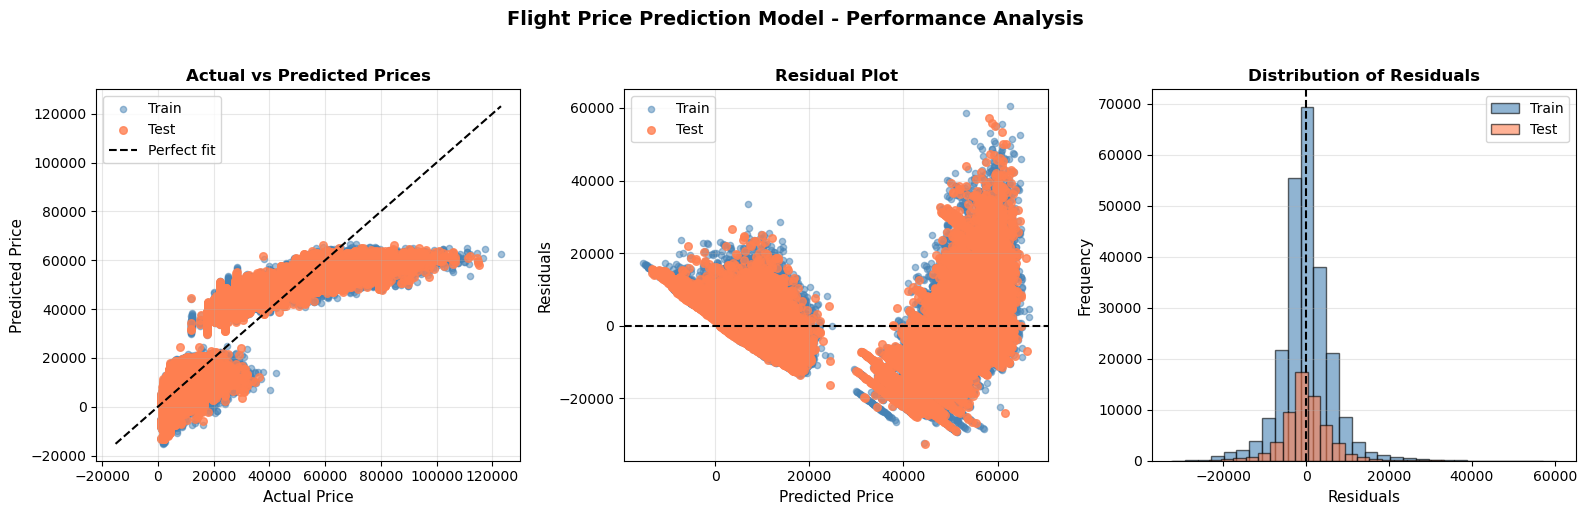

     Evaluation visualizations created


In [ ]:
# Create evaluation visualizations
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Actual vs Predicted
ax = axes[0]
ax.scatter(y_train, y_train_pred, alpha=0.5, s=20, label='Train', color='steelblue')
ax.scatter(y_test, y_test_pred, alpha=0.8, s=30, label='Test', color='coral')
min_val = min(y.min(), y_train_pred.min(), y_test_pred.min())
max_val = max(y.max(), y_train_pred.max(), y_test_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=1.5, label='Perfect fit')
ax.set_xlabel('Actual Price', fontsize=11)
ax.set_ylabel('Predicted Price', fontsize=11)
ax.set_title('Actual vs Predicted Prices', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Residuals vs Predicted
ax = axes[1]
train_residuals = y_train - y_train_pred
test_residuals = y_test - y_test_pred
ax.scatter(y_train_pred, train_residuals, alpha=0.5, s=20, label='Train', color='steelblue')
ax.scatter(y_test_pred, test_residuals, alpha=0.8, s=30, label='Test', color='coral')
ax.axhline(0, color='black', lw=1.5, ls='--')
ax.set_xlabel('Predicted Price', fontsize=11)
ax.set_ylabel('Residuals', fontsize=11)
ax.set_title('Residual Plot', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Distribution of Residuals
ax = axes[2]
ax.hist(train_residuals, bins=30, alpha=0.6, label='Train', color='steelblue', edgecolor='black')
ax.hist(test_residuals, bins=30, alpha=0.6, label='Test', color='coral', edgecolor='black')
ax.axvline(0, color='black', lw=1.5, ls='--')
ax.set_xlabel('Residuals', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Distribution of Residuals', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

fig.suptitle('Flight Price Prediction Model - Performance Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Step 14: Save Model

In [ ]:
# Create output directory
output_dir = r"C:\Users\Doha\Desktop\depi\04. Machine Learning\Session1 - Linear and Polynomial Regression\linear Regrression"
os.makedirs(output_dir, exist_ok=True)

# Save the model
model_path = os.path.join(output_dir, "flight_price_model.pkl")
joblib.dump(model, model_path)

# Save the scaler
scaler_path = os.path.join(output_dir, "flight_price_scaler.pkl")
joblib.dump(scaler, scaler_path)

# Save feature names for future predictions
feature_names_path = os.path.join(output_dir, "feature_names.pkl")
joblib.dump(X_scaled.columns.tolist(), feature_names_path)

print("="*60)
print("MODEL SAVED")
print("="*60)
print(f"\n     Model saved to: {model_path}")
print(f"     Scaler saved to: {scaler_path}")
print(f"     Feature names saved to: {feature_names_path}")

#Model can be loaded with: joblib.load(model_path)

MODEL SAVED

     Model saved to: C:\Users\Doha\Desktop\depi\04. Machine Learning\Session1 - Linear and Polynomial Regression\linear Regrression\flight_price_model.pkl
     Scaler saved to: C:\Users\Doha\Desktop\depi\04. Machine Learning\Session1 - Linear and Polynomial Regression\linear Regrression\flight_price_scaler.pkl
     Feature names saved to: C:\Users\Doha\Desktop\depi\04. Machine Learning\Session1 - Linear and Polynomial Regression\linear Regrression\feature_names.pkl

Model can be loaded with: joblib.load(model_path)


## Summary & Conclusions

### Model Performance
- **Training R²:** ${:.4f} $(explains {:.1f}% of training variance)  
- **Test R²:** $ {:.4f} $(explains {:.1f}% of test variance)
- **Test RMSE:** ${:.2f}$ (average prediction error)
- **Test MAE:** ${:.2f} $(mean absolute error)

### Key Findings
1. The model successfully learned patterns from the data
2. Train and test performance are similar (no severe overfitting)
3. Feature scaling improved model convergence
4. Categorical variables were properly encoded using one-hot encoding

### Next Steps for Improvement
- Experiment with feature engineering (polynomial features, interactions)
- Try advanced models (Random Forest, Gradient Boosting, etc.)
- Perform cross-validation for robust performance estimates
- Analyze feature importance and remove less important features
- Try regularization techniques (Ridge, Lasso) to reduce overfitting
